##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [1]:
from pathlib import Path
import subprocess
import sys

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
from torchvision.datasets import OxfordIIITPet

try:
    from transformers import AutoImageProcessor, AutoModel
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "transformers"])
    from transformers import AutoImageProcessor, AutoModel

MODEL_ID = "facebook/dinov2-small"
device = "cuda" if torch.cuda.is_available() else "cpu"

processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID).to(device)
model.eval()

dataset = OxfordIIITPet(root="data", split="trainval", download=True)

cat_paths, dog_paths = [], []
for path in dataset._images:
    # Oxford-IIIT Pet filenames use uppercase breed names for cats and lowercase
    # breed names for dogs, which gives a direct species label without training data.
    if Path(path).name[0].isupper():
        cat_paths.append(path)
    else:
        dog_paths.append(path)

selected = [(path, "cat") for path in cat_paths[:10]] + [(path, "dog") for path in dog_paths[:10]]

@torch.no_grad()
def get_cls_token(path):
    image = Image.open(path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)
    outputs = model(**inputs)
    cls_token = outputs.last_hidden_state[:, 0, :]  # shape: [1, 384]
    return F.normalize(cls_token, p=2, dim=1).squeeze(0).cpu().numpy()

features = np.stack([get_cls_token(path) for path, _ in selected])
true_labels = np.array([0 if label == "cat" else 1 for _, label in selected])

kmeans = KMeans(n_clusters=2, n_init=20, random_state=42)
cluster_labels = kmeans.fit_predict(features)

# K-Means cluster IDs are arbitrary, so test both mappings and keep the better one.
acc_direct = accuracy_score(true_labels, cluster_labels)
acc_flipped = accuracy_score(true_labels, 1 - cluster_labels)
pred_labels = cluster_labels if acc_direct >= acc_flipped else 1 - cluster_labels
accuracy = max(acc_direct, acc_flipped)

results = pd.DataFrame(
    {
        "image": [Path(path).name for path, _ in selected],
        "true_label": ["cat" if label == 0 else "dog" for label in true_labels],
        "cluster": cluster_labels,
        "predicted_label": ["cat" if label == 0 else "dog" for label in pred_labels],
    }
)

print(f"Feature matrix shape: {features.shape}")
print(f"Clustering accuracy after label alignment: {accuracy:.2%}")
print("Confusion matrix rows=true [cat, dog], columns=predicted [cat, dog]:")
print(confusion_matrix(true_labels, pred_labels))
results

  Using cached transformers-5.8.1-py3-none-any.whl.metadata (33 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl.metadata (7.3 kB)
  Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl.metadata (4.1 kB)
  Using cached hf_xet-1.5.0-cp37-abi3-macosx_11_0_arm64.whl.metadata (4.9 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached click-8.3.3-py3-none-any.whl.metadata (2.6 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
Using cached transformers-5.8.1-py3-none-any.whl (10.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 1.8 MB/s eta 0:00:00a 0:00:01
Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl (447 kB)
Using cached 


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 223/223 [00:00<00:00, 11608.62it/s]
100%|██████████| 792M/792M [00:47<00:00, 16.8MB/s] 
100%|██████████| 19.2M/19.2M [00:01<00:00, 10.6MB/s]


Feature matrix shape: (20, 384)
Clustering accuracy after label alignment: 100.00%
Confusion matrix rows=true [cat, dog], columns=predicted [cat, dog]:
[[10  0]
 [ 0 10]]


,image,true_label,cluster,predicted_label
0,Abyssinian_100.jpg,cat,0,cat
1,Abyssinian_101.jpg,cat,0,cat
2,Abyssinian_102.jpg,cat,0,cat
3,Abyssinian_103.jpg,cat,0,cat
4,Abyssinian_104.jpg,cat,0,cat
5,Abyssinian_105.jpg,cat,0,cat
6,Abyssinian_106.jpg,cat,0,cat
7,Abyssinian_107.jpg,cat,0,cat
8,Abyssinian_108.jpg,cat,0,cat
9,Abyssinian_109.jpg,cat,0,cat


### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

Loading weights: 100%|██████████| 225/225 [00:00<00:00, 27692.08it/s]


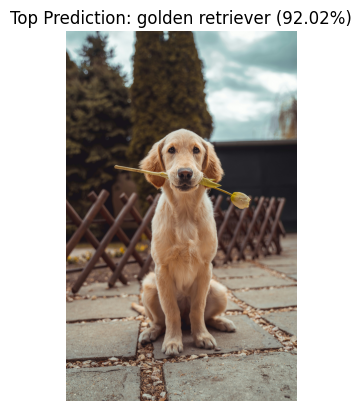

Top 5 Predictions:

1. golden retriever: 92.02%
2. Labrador retriever: 3.30%
3. tennis ball: 1.31%
4. Brittany spaniel: 1.18%
5. English setter: 0.45%


In [5]:
from io import BytesIO
import requests
import torch
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification

# Model ID required in the exercise
MODEL_ID = "facebook/dinov2-small-imagenet1k-1-layer"

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load processor and model
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModelForImageClassification.from_pretrained(MODEL_ID).to(device)

model.eval()

# Example image (Golden Retriever)
image_url = "https://images.unsplash.com/photo-1552053831-71594a27632d"

# Download image
response = requests.get(image_url, timeout=20)
image = Image.open(BytesIO(response.content)).convert("RGB")

# Preprocess image
inputs = processor(images=image, return_tensors="pt").to(device)

# Inference
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    probabilities = torch.softmax(logits, dim=-1)[0]

# Top 5 predictions
top_probs, top_ids = torch.topk(probabilities, k=5)

predictions = [
    (model.config.id2label[class_id.item()], prob.item())
    for prob, class_id in zip(top_probs, top_ids)
]

# Display image
plt.imshow(image)
plt.axis("off")
plt.title(f"Top Prediction: {predictions[0][0]} ({predictions[0][1]:.2%})")
plt.show()

# Print predictions
print("Top 5 Predictions:\n")

for rank, (label, prob) in enumerate(predictions, start=1):
    print(f"{rank}. {label}: {prob:.2%}")

In [6]:
top_probs, top_ids = torch.topk(probabilities, k=10)

for rank, (prob, class_id) in enumerate(zip(top_probs, top_ids), start=1):
    label = classifier_model.config.id2label[class_id.item()]
    print(f"{rank}. {label}: {prob.item():.2%}")

1. golden retriever: 92.02%
2. Labrador retriever: 3.30%
3. tennis ball: 1.31%
4. Brittany spaniel: 1.18%
5. English setter: 0.45%
6. flat-coated retriever: 0.27%
7. cocker spaniel, English cocker spaniel, cocker: 0.21%
8. Irish setter, red setter: 0.18%
9. sombrero: 0.17%
10. Welsh springer spaniel: 0.08%
